In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from grid_determination_bizom.constant import COLS_TO_KEEP_1, COLS_TO_KEEP_2
from grid_determination_bizom.data_pipeline.data_aggregation import (
    DataAggregator,
    convert_to_dataframe,
)

In [2]:
FILE_PATH = "/Users/saranyapal/Developer/grid-determination-bizom/data/delhi_grids.csv"
raw_df = convert_to_dataframe(FILE_PATH)
transformer = DataAggregator(df=raw_df)
master_df = transformer()

print(f"Master DataFrame shape: {master_df.shape}")

Extracting Image Features: 100%|██████████| 2000/2000 [00:02<00:00, 831.19it/s]

Master DataFrame shape: (2000, 27)


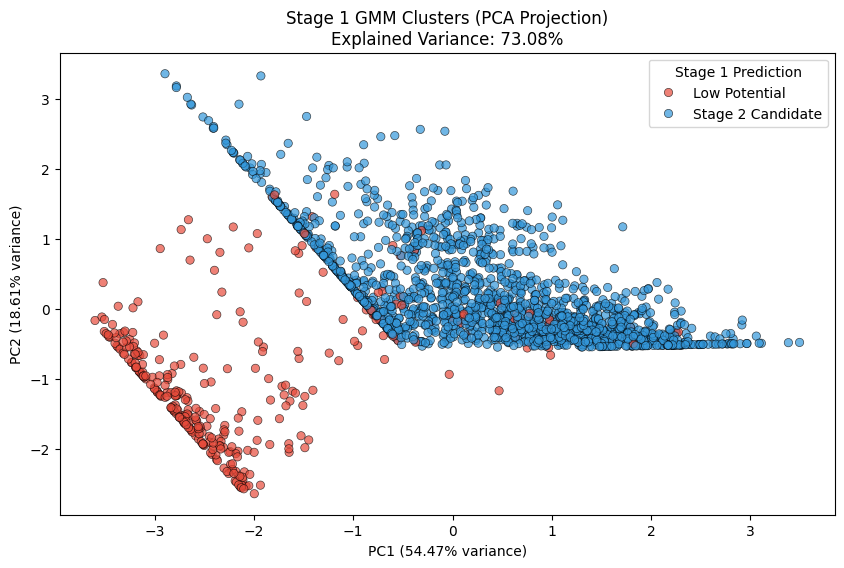

Stage 1 Distribution:
predicted_potential
Stage 2 Candidate    1662
Low Potential         338
Name: count, dtype: int64


In [3]:
stage_1_features = master_df[COLS_TO_KEEP_1]
X_scaled_1 = StandardScaler().fit_transform(stage_1_features)

gmm_1 = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
labels_1 = gmm_1.fit_predict(X_scaled_1)

temp_df = master_df.copy()
temp_df["stage_1_labels"] = labels_1

median_0 = temp_df[temp_df["stage_1_labels"] == 0]["yellow_building_count"].median()
median_1 = temp_df[temp_df["stage_1_labels"] == 1]["yellow_building_count"].median()
low_cluster_id = 0 if median_0 < median_1 else 1

string_labels_1 = [
    "Low Potential" if l == low_cluster_id else "Stage 2 Candidate" for l in labels_1
]
temp_df["predicted_potential"] = string_labels_1
pca_1 = PCA(n_components=2)
X_pca_1 = pca_1.fit_transform(X_scaled_1)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_1[:, 0],
    y=X_pca_1[:, 1],
    hue=string_labels_1,
    palette={"Low Potential": "#e74c3c", "Stage 2 Candidate": "#3498db"},
    alpha=0.7,
    edgecolor="k",
)
plt.title(
    f"Stage 1 GMM Clusters (PCA Projection)\nExplained Variance: {pca_1.explained_variance_ratio_.sum():.2%}"
)
plt.xlabel(f"PC1 ({pca_1.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_1.explained_variance_ratio_[1]:.2%} variance)")
plt.legend(title="Stage 1 Prediction")
plt.show()

print("Stage 1 Distribution:")
print(temp_df["predicted_potential"].value_counts())

In [7]:
print(median_1)

0.0


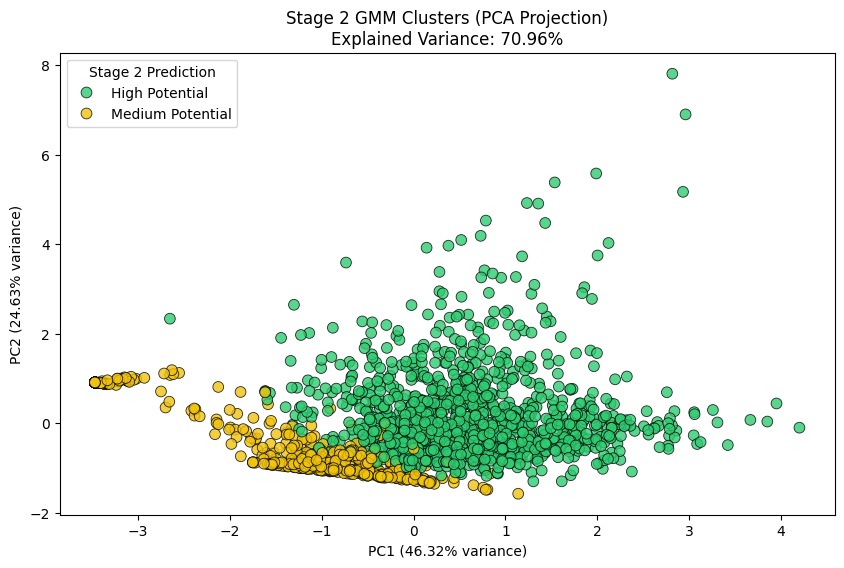

Stage 2 Distribution:
final_potential
High Potential      1159
Medium Potential     503
Name: count, dtype: int64


In [ ]:
candidate_df = temp_df[temp_df["predicted_potential"] == "Stage 2 Candidate"].copy()
stage_2_features = candidate_df[COLS_TO_KEEP_2]
X_scaled_2 = StandardScaler().fit_transform(stage_2_features)

gmm_2 = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
labels_2 = gmm_2.fit_predict(X_scaled_2)
candidate_df["stage_2_labels"] = labels_2

median_0_s2 = candidate_df[candidate_df["stage_2_labels"] == 0][
    "yellow_building_count"
].median()
median_1_s2 = candidate_df[candidate_df["stage_2_labels"] == 1][
    "yellow_building_count"
].median()
medium_cluster_id = 0 if median_0_s2 < median_1_s2 else 1

string_labels_2 = [
    "Medium Potential" if l == medium_cluster_id else "High Potential" for l in labels_2
]
candidate_df["final_potential"] = string_labels_2

pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled_2)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_pca_2[:, 0],
    y=X_pca_2[:, 1],
    hue=string_labels_2,
    palette={"Medium Potential": "#f1c40f", "High Potential": "#2ecc71"},
    alpha=0.8,
    edgecolor="k",
    s=60,
)
plt.title(
    f"Stage 2 GMM Clusters (PCA Projection)\nExplained Variance: {pca_2.explained_variance_ratio_.sum():.2%}"
)
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]:.2%} variance)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]:.2%} variance)")
plt.legend(title="Stage 2 Prediction")
plt.show()

print("Stage 2 Distribution:")
print(candidate_df["final_potential"].value_counts())

In [6]:
print(median_0_s2)
print(median_1_s2)

11.0
1.0
